#  🏦 Bank Loan Analysis

<img src="Bank Loan .png" width="900">

             BANK LOAN ANALYSIS

    Exploratory Data Analysis using Python

Objective:

To analyze bank loan data, identify important patterns and trends,
and understand the factors that influence loan applications and approvals.

Dataset Overview

A financial institution wants to understand loan application and customer behaviour to evaluate loan performance and identify factors associated with successful and unsuccessful loans.

The dataset contains 38,576 loan records with 24 variables, including customer demographics, employment details, annual income, home ownership, loan amount, loan purpose, loan grade, interest rate, credit history, and debt-to-income ratio (DTI).

It also contains loan status, payment information, verification details, and credit-related attributes, which can be used to analyze loan performance, repayment behaviour, and customer financial profiles.

The objective is to perform exploratory data analysis to identify patterns and key factors influencing loan outcomes, helping the financial institution make better lending, risk assessment, and customer management decisions.

#  IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [ ]:
df = pd.read_excel(r"C:/Users/Preethika Roshini/Downloads/financial_loan.xlsx")

In [ ]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


# MetaData of Data

In [ ]:
print("No.of.Rows:",df.shape[0])

No.of.Rows: 38576


In [ ]:
print("No.of.Columns:",df.shape[1])

No.of.Columns: 24


In [ ]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

In [ ]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [ ]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


## TOTAL LOAN APPLICATIONS

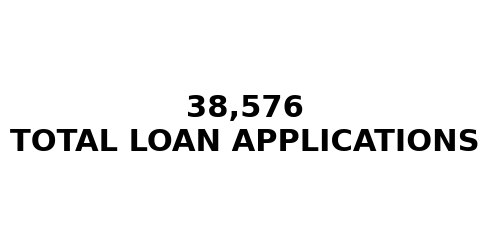

In [ ]:
total_loan_applications = df['id'].count()
plt.figure(figsize=(6,3));
plt.text(.5,.5,f"{total_loan_applications:,}\nTOTAL LOAN APPLICATIONS",ha='center',va='center',fontsize=22,fontweight='bold');
plt.axis('off');
plt.show()

### MTD TOTAL LOAN APPLICATION

In [ ]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) &(df['issue_date'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications (for {latest_issue_date.strftime ('%B %Y')}) : {mtd_loan_applications}")



MTD Loan Applications (for December 2021) : 4314


###

### TOTAL FUNDED AMOUNT

In [ ]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/ 1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))


Total Funded Amount: $435.76M


### MTD TOTAL

In [ ]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) &(df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/ 1000000
print("MTD Total Funded Amount: ${:.2f}M".format(mtd_total_funded_amount_millions))


MTD Total Funded Amount: $53.98M


### TOTAL AMOUNT RECEIVED

In [ ]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_funded_amount/ 1000000
print("Total amount_received: ${:.2f}M".format(total_amount_received_millions))

Total amount_received: $435.76M


### MTD TOTAL AMOUNT RECEIVED

In [ ]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) &(df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received= mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received/ 1000000
print("MTD Total Amount Recieved: ${:.2f}M".format(mtd_total_amount_received_millions))

MTD Total Amount Recieved: $58.07M


### AVERAGE INTEREST RATE

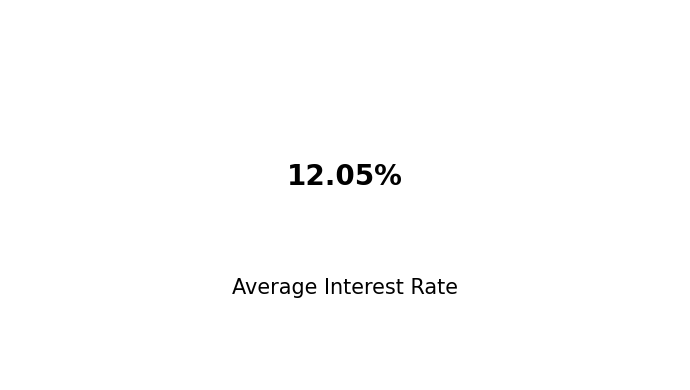

In [ ]:
plt.figure(figsize=(7, 4))

plt.text(0.5, 0.55,f"{average_interest_rate:.2f}%",ha='center',va='center',fontsize=,fontweight='bold')

plt.text(0.5, 0.25,"Average Interest Rate",ha='center',va='center',fontsize=15)

plt.axis('off')
plt.tight_layout()
plt.show()

### AVERAGE DEPT-TO-INCOME RATIO

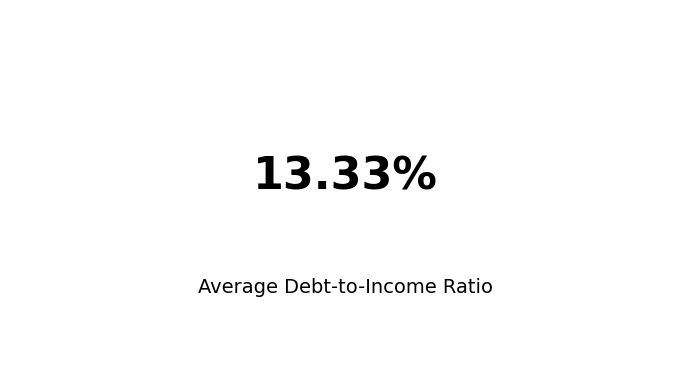

In [ ]:
plt.figure(figsize=(7, 4))

plt.text(0.5, 0.55,f"{average_dti:.2f}%",ha='center',va='center',fontsize=32,fontweight='bold')

plt.text(0.5, 0.25,"Average Debt-to-Income Ratio",ha='center',va='center',fontsize=14)

plt.axis('off')
plt.tight_layout()
plt.show()

### GOOD LOAN METRICS

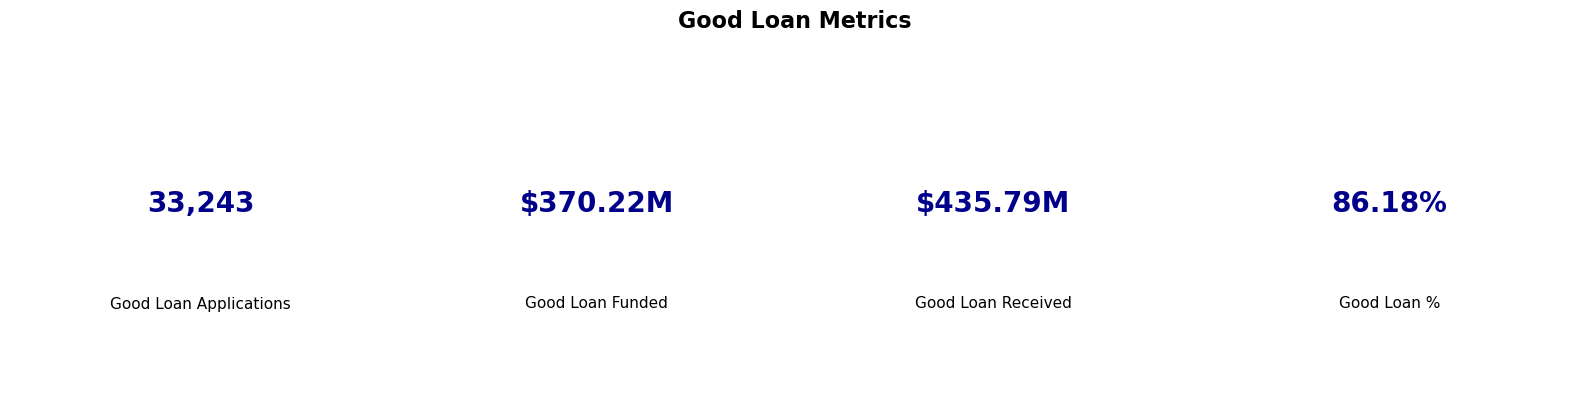

In [ ]:
metrics = {'Good Loan Applications': f'{good_loan_applications:,}',
    'Good Loan Funded': f'${good_loan_funded_amount_millions:.2f}M',
    'Good Loan Received': f'${good_loan_received_millions:.2f}M',
    'Good Loan %': f'{good_loan_percentage:.2f}%'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (title, value) in zip(axes, metrics.items()):
    ax.text(0.5, 0.55,value,ha='center',va='center',fontsize=20,fontweight='bold',color='darkblue')
    ax.text(0.5, 0.25,title,ha='center',va='center',fontsize=11)
    ax.axis('off')

plt.suptitle('Good Loan Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### BAD LOAN METRICS

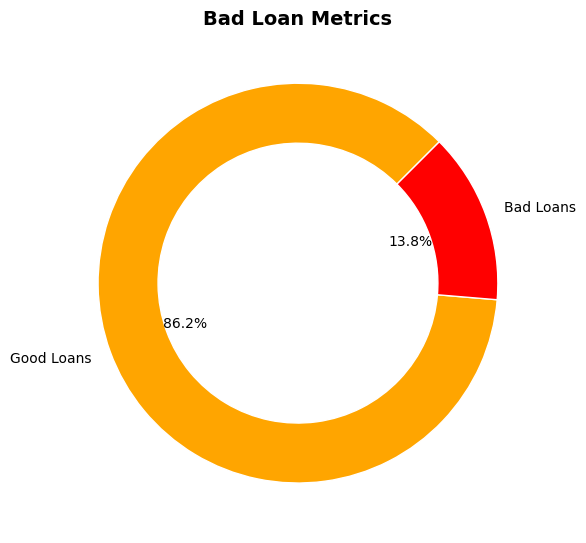

In [ ]:
# Calculate Good & Bad Loan Applications
good_loans = df[df['loan_status'].isin(['Fully Paid', 'Current'])]['id'].count()
bad_loans = df[df['loan_status'] == 'Charged Off']['id'].count()

labels = ['Good Loans', 'Bad Loans']
sizes = [good_loans, bad_loans]
colors = ['Orange', 'Red']

plt.figure(figsize=(6,6))

plt.pie(sizes,labels=labels,colors=colors,autopct='%1.1f%%',startangle=45,wedgeprops={'width':0.30, 'edgecolor':'white'})

plt.title('Bad Loan Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### MONTHLY TRENDS BY ISSUE DATE FOR TOTAL FUNDED AMOUNT

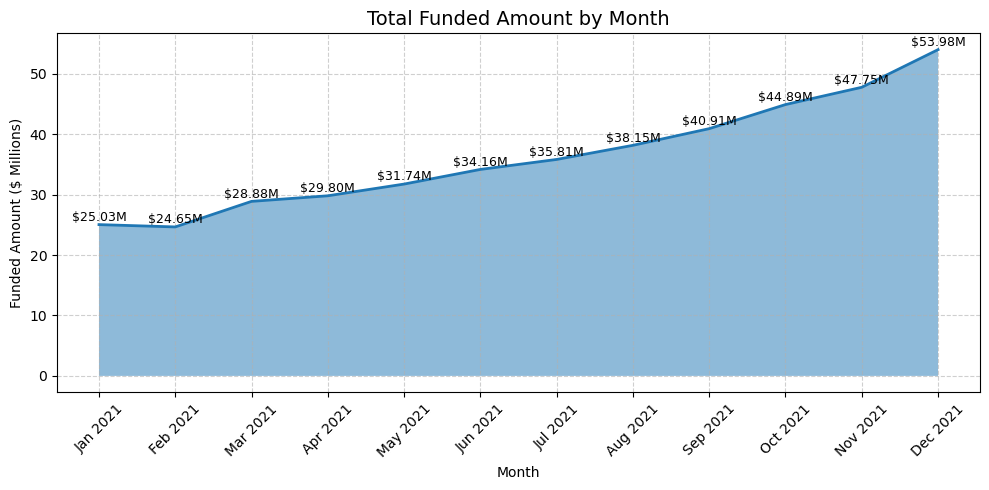

In [ ]:
df['issue_date'] = pd.to_datetime(df['issue_date'])

monthly_funded = (df.sort_values('issue_date').assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['loan_amount'].sum().div(1_000_000).reset_index(name='loan_amount_millions'))

plt.figure(figsize=(10, 5))

plt.fill_between(range(len(monthly_funded)),monthly_funded['loan_amount_millions'],alpha=0.5)

plt.plot(range(len(monthly_funded)),monthly_funded['loan_amount_millions'],linewidth=2)

for i, row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_millions'] + 0.1,f"${row['loan_amount_millions']:.2f}M",ha='center',va='bottom',fontsize=9)

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')

plt.xticks(range(len(monthly_funded)),monthly_funded['month_name'],rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### MONTHLY TRENDS BY ISSUE DATE FOR TOTAL AMOUNT

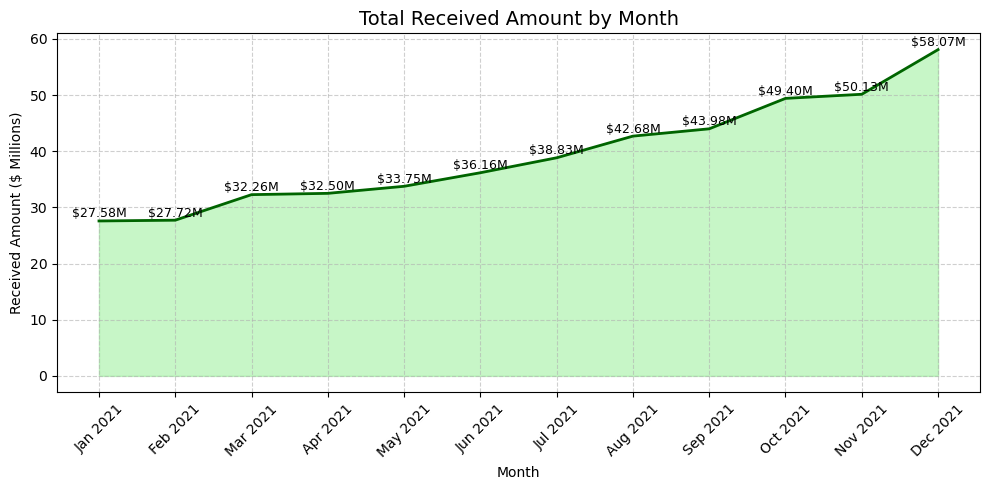

In [ ]:
monthly_received = (df.sort_values('issue_date').assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment'].sum().div(1_000_000).reset_index(name='received_amount_millions'))

plt.figure(figsize=(10, 5))

plt.fill_between(range(len(monthly_received)),monthly_received['received_amount_millions'],color='lightgreen',alpha=0.5)

plt.plot(range(len(monthly_received)),monthly_received['received_amount_millions'],color='darkgreen',linewidth=2)

for i, row in monthly_received.iterrows():
    plt.text(i,row['received_amount_millions'] + 0.1,f"${row['received_amount_millions']:.2f}M",ha='center',va='bottom',fontsize=9)

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount ($ Millions)')

plt.xticks(ticks=range(len(monthly_received)),labels=monthly_received['month_name'],rotation=4)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MONTHLY TRENDS BY ISSUE DATE FOR TOTAL LOAN APPLICATIONS

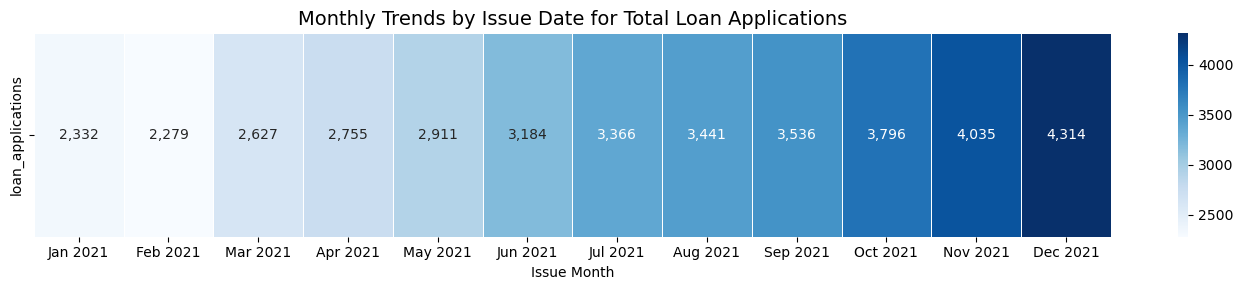

In [ ]:
# Create monthly loan application count
monthly_applications = (df.sort_values('issue_date').assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['id'].count().reset_index(name='loan_applications'))

# Convert to heatmap format
heatmap_data = monthly_applications.set_index('month_name').T

# Create heatmap
plt.figure(figsize=(14, 3))

sns.heatmap(heatmap_data,annot=True,fmt=',d',cmap='Blues',linewidths=0.5)

plt.title('Monthly Trends by Issue Date for Total Loan Applications', fontsize=14)
plt.xlabel('Issue Month')
plt.ylabel('')

plt.tight_layout()
plt.show()